<a href="https://colab.research.google.com/github/NAYANDEEPSINGH/Stock-Market-Forecasting/blob/main/Knn_Trading_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-plot

In [2]:
pip install xgboost

In [3]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

from xgboost import XGBClassifier, plot_importance, Booster, plot_tree, to_graphviz



#KNN Classifier
from sklearn.neighbors import KNeighborsClassifier





from sklearn.ensemble import BaggingClassifier

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, cross_val_score, GridSearchCV


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,auc, roc_curve
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error

from sklearn import metrics


import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
uploaded = files.upload()

Saving AAPL.csv to AAPL.csv


In [5]:

df = pd.read_csv('AAPL.csv', index_col=0, parse_dates=True)

#parse_dates=True means information should be in time series format.
df['Returns'] = np.log(df).diff()
df.head()

,AAPL,Returns
Date,,
1999-12-31,0.778144,NaN
2000-01-03,0.847207,0.085033
2000-01-04,0.775779,-0.088078
2000-01-05,0.787131,0.014527
2000-01-06,0.719014,-0.090514


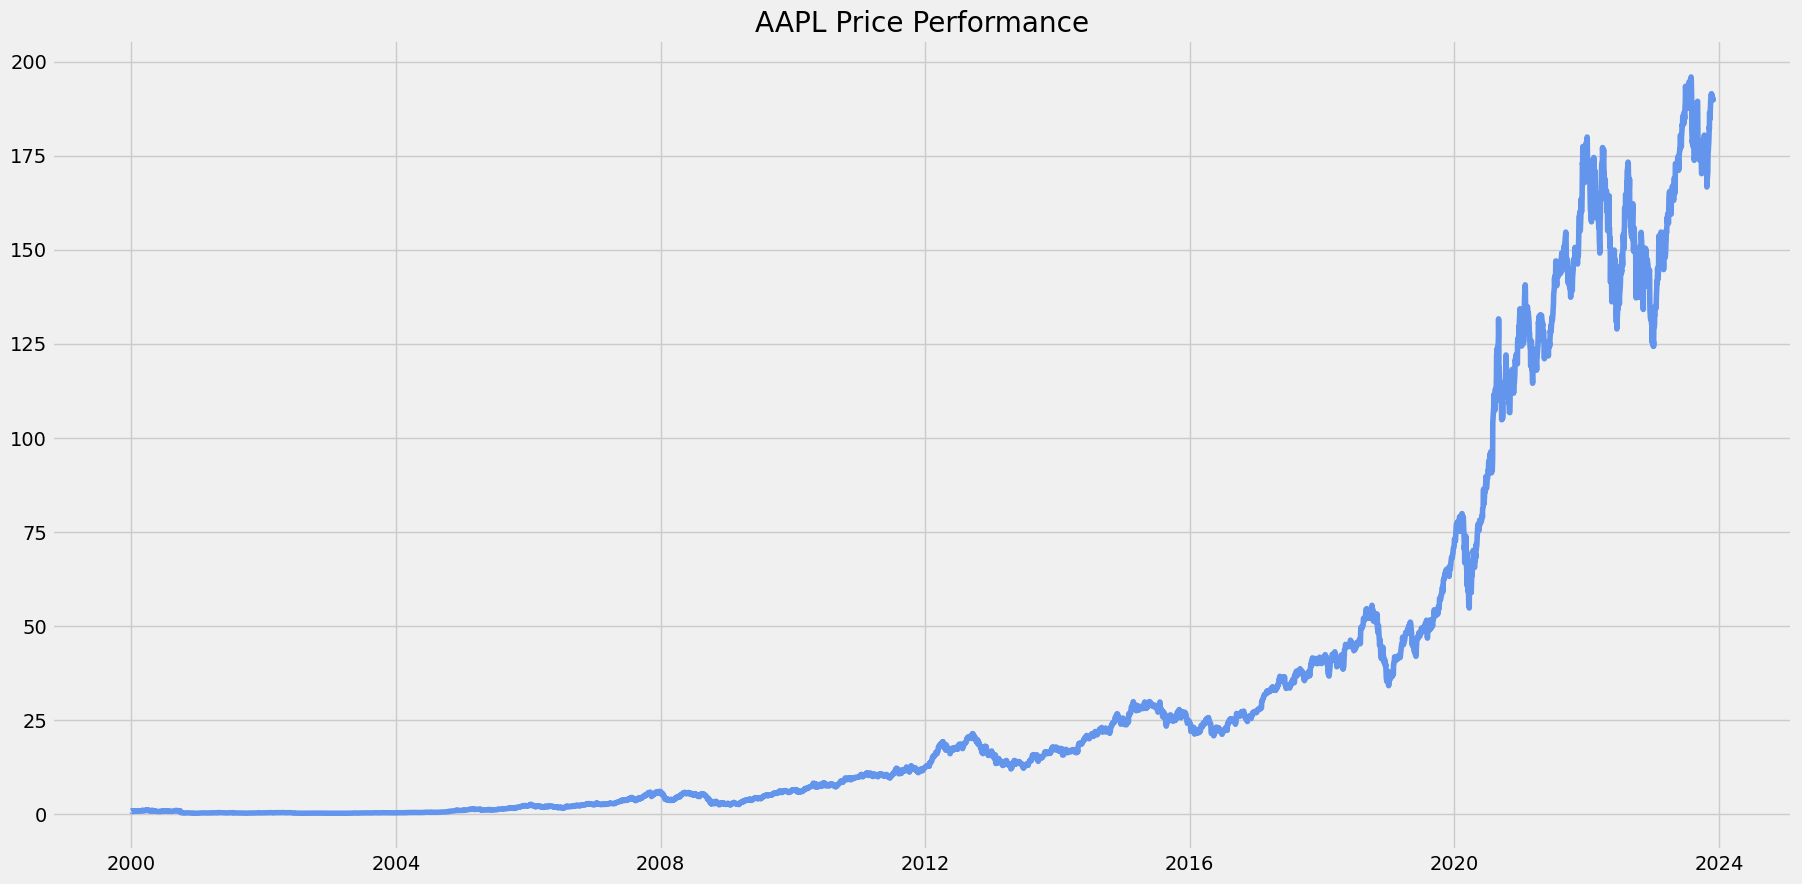

In [6]:
plt.figure(figsize=(20,10))
plt.title('AAPL Price Performance')
plt.plot(df['AAPL'], color='cornflowerblue');

In [7]:
df.tail()

,AAPL,Returns
Date,,
2023-11-22,191.309998,0.003508
2023-11-24,189.970001,-0.007029
2023-11-27,189.789993,-0.000948
2023-11-28,190.399994,0.003209
2023-11-29,189.369995,-0.005424


In [8]:
features_list = []
for r in range(10, 65, 5):
    df['Ret_'+str(r)] = df.Returns.rolling(r).sum()
    df['Std_'+str(r)] = df.Returns.rolling(r).std()
    features_list.append('Ret_'+str(r))
    features_list.append('Std_'+str(r))

df.dropna(inplace=True)

In [9]:
df.head()

,AAPL,Returns,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,...,Ret_40,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60
Date,,,,,,,,,,,,,,,,,,,,,
2000-03-28,1.052977,-0.003140,0.196984,0.038352,0.124205,0.039488,0.193706,0.048628,0.200821,0.044890,...,0.293389,0.041296,0.269578,0.041863,0.325838,0.041630,0.335215,0.043912,0.302466,0.046973
2000-03-29,1.028853,-0.023177,0.156453,0.040697,0.108174,0.040147,0.042261,0.040263,0.156453,0.045224,...,0.304529,0.041045,0.191467,0.041405,0.268406,0.041642,0.329782,0.043973,0.194255,0.045915
2000-03-30,0.951748,-0.077899,0.033868,0.048661,0.028228,0.045791,0.030275,0.041402,0.087600,0.048194,...,0.241072,0.043095,0.132113,0.043060,0.165565,0.043167,0.304389,0.044726,0.204433,0.045590
2000-03-31,1.027907,0.076979,0.082962,0.053630,0.076979,0.049384,0.059245,0.043564,0.207392,0.049339,...,0.273517,0.044131,0.210795,0.044442,0.179472,0.043603,0.443214,0.044770,0.266885,0.046551
2000-04-03,1.008985,-0.018580,0.080512,0.053760,0.094326,0.048550,0.058897,0.043573,0.163098,0.049482,...,0.210564,0.043880,0.271406,0.042728,0.180354,0.043593,0.320566,0.042915,0.338819,0.044963


In [10]:
df['Adj Close'] = df['AAPL']

In [11]:
df.head()

,AAPL,Returns,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,...,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60,Adj Close
Date,,,,,,,,,,,,,,,,,,,,,
2000-03-28,1.052977,-0.003140,0.196984,0.038352,0.124205,0.039488,0.193706,0.048628,0.200821,0.044890,...,0.041296,0.269578,0.041863,0.325838,0.041630,0.335215,0.043912,0.302466,0.046973,1.052977
2000-03-29,1.028853,-0.023177,0.156453,0.040697,0.108174,0.040147,0.042261,0.040263,0.156453,0.045224,...,0.041045,0.191467,0.041405,0.268406,0.041642,0.329782,0.043973,0.194255,0.045915,1.028853
2000-03-30,0.951748,-0.077899,0.033868,0.048661,0.028228,0.045791,0.030275,0.041402,0.087600,0.048194,...,0.043095,0.132113,0.043060,0.165565,0.043167,0.304389,0.044726,0.204433,0.045590,0.951748
2000-03-31,1.027907,0.076979,0.082962,0.053630,0.076979,0.049384,0.059245,0.043564,0.207392,0.049339,...,0.044131,0.210795,0.044442,0.179472,0.043603,0.443214,0.044770,0.266885,0.046551,1.027907
2000-04-03,1.008985,-0.018580,0.080512,0.053760,0.094326,0.048550,0.058897,0.043573,0.163098,0.049482,...,0.043880,0.271406,0.042728,0.180354,0.043593,0.320566,0.042915,0.338819,0.044963,1.008985


In [12]:
df['Target'] = np.where(df['Adj Close'].shift(-1)>.995*df['Adj Close'],1,-1)

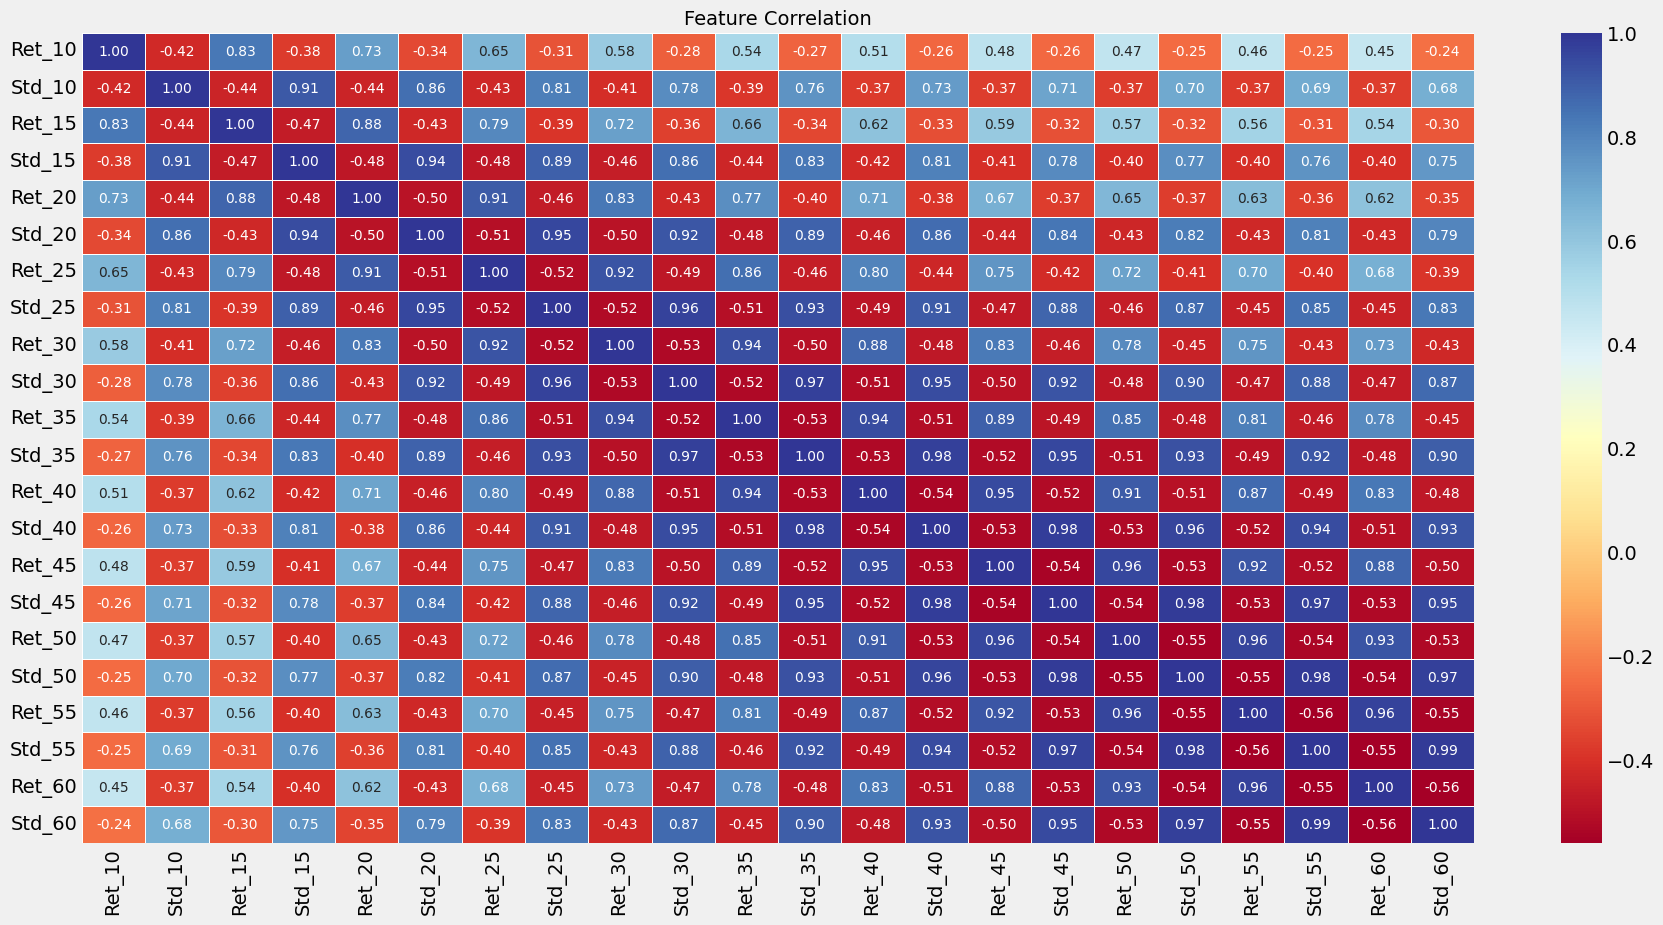

In [13]:
import seaborn as sns
corrmat = df.drop(['Adj Close','AAPL', 'Returns', 'Target'],axis=1).corr()


fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(corrmat, annot=True, annot_kws={"size": 10}, fmt="0.2f", linewidths=0.5, square=False, cbar=True, cmap='RdYlBu')
ax.set_title('Feature Correlation', fontsize=14, color='black');

In [14]:
X = df.drop(['Adj Close', 'Returns', 'Target','AAPL'],axis=1)

X

,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,Ret_30,Std_30,...,Ret_40,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60
Date,,,,,,,,,,,,,,,,,,,,,
2000-03-28,0.196984,0.038352,0.124205,0.039488,0.193706,0.048628,0.200821,0.044890,0.183401,0.042723,...,0.293389,0.041296,0.269578,0.041863,0.325838,0.041630,0.335215,0.043912,0.302466,0.046973
2000-03-29,0.156453,0.040697,0.108174,0.040147,0.042261,0.040263,0.156453,0.045224,0.133072,0.042856,...,0.304529,0.041045,0.191467,0.041405,0.268406,0.041642,0.329782,0.043973,0.194255,0.045915
2000-03-30,0.033868,0.048661,0.028228,0.045791,0.030275,0.041402,0.087600,0.048194,0.097002,0.044666,...,0.241072,0.043095,0.132113,0.043060,0.165565,0.043167,0.304389,0.044726,0.204433,0.045590
2000-03-31,0.082962,0.053630,0.076979,0.049384,0.059245,0.043564,0.207392,0.049339,0.167431,0.046653,...,0.273517,0.044131,0.210795,0.044442,0.179472,0.043603,0.443214,0.044770,0.266885,0.046551
2000-04-03,0.080512,0.053760,0.094326,0.048550,0.058897,0.043573,0.163098,0.049482,0.180916,0.046342,...,0.210564,0.043880,0.271406,0.042728,0.180354,0.043593,0.320566,0.042915,0.338819,0.044963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-22,0.046327,0.009431,0.096329,0.009612,0.112963,0.011379,0.085637,0.011583,0.063367,0.011212,...,0.116887,0.010365,0.087630,0.010829,0.094950,0.011039,0.046217,0.011775,0.039624,0.012530
2023-11-24,0.041926,0.009899,0.068818,0.009359,0.130848,0.009377,0.080772,0.011721,0.051289,0.011320,...,0.108334,0.010483,0.089530,0.010789,0.079177,0.011065,0.068874,0.011063,0.013604,0.012334
2023-11-27,0.018023,0.007447,0.073064,0.009103,0.121962,0.009517,0.094637,0.011146,0.060687,0.011102,...,0.104344,0.010498,0.083650,0.010788,0.082392,0.011040,0.064441,0.011062,0.011485,0.012334


In [15]:
X.shape

(5957, 22)

In [16]:
y = df['Target']
y

,Target
Date,
2000-03-28,-1
2000-03-29,-1
2000-03-30,1
2000-03-31,-1
2000-04-03,-1
...,...
2023-11-22,-1
2023-11-24,1
2023-11-27,1


In [17]:
y.shape

(5957,)

In [18]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 4765, 1192


In [19]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', KNeighborsClassifier())])

In [20]:
# Target classes
class_names = pipe.classes_
class_names#keeps the output

array([-1,  1])

In [21]:
y_pred = pipe.predict(X_test)

In [22]:
acc_train = accuracy_score(y_train, pipe.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

In [23]:
print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7429, Test Accuracy: 0.5998


In [24]:
print(metrics.confusion_matrix(y_test, y_pred))

[[103 289]
 [188 612]]


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.35      0.26      0.30       392
           1       0.68      0.77      0.72       800

    accuracy                           0.60      1192
   macro avg       0.52      0.51      0.51      1192
weighted avg       0.57      0.60      0.58      1192



In [26]:
pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()), ('classifier', KNeighborsClassifier())],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'classifier': KNeighborsClassifier(),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'classifier__algorithm': 'auto',
 'classifier__leaf_size': 30,
 'classifier__metric': 'minkowski',
 'classifier__metric_params': None,
 'classifier__n_jobs': None,
 'classifier__n_neighbors': 5,
 'classifier__p': 2,
 'classifier__weights': 'uniform'}

In [28]:
tscv = TimeSeriesSplit(n_splits=3)
for train, test in tscv.split(X):
    print(train, test)

[   0    1    2 ... 1487 1488 1489] [1490 1491 1492 ... 2976 2977 2978]
[   0    1    2 ... 2976 2977 2978] [2979 2980 2981 ... 4465 4466 4467]
[   0    1    2 ... 4465 4466 4467] [4468 4469 4470 ... 5954 5955 5956]


In [29]:
param_grid = {"classifier__n_neighbors": np.arange(1,51,1)}

grid_search = GridSearchCV(pipe, param_grid, scoring='roc_auc', n_jobs=-1, cv=tscv, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])},
             scoring='roc_auc', verbose=1)

In [30]:
grid_search.best_params_

{'classifier__n_neighbors': np.int64(48)}

In [31]:
grid_search.best_score_

np.float64(0.5452948367740938)

In [32]:
error_rate = []
acc_score = []

for i in range(1,51):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
    acc_score.append(accuracy_score(y_test, pred_i))

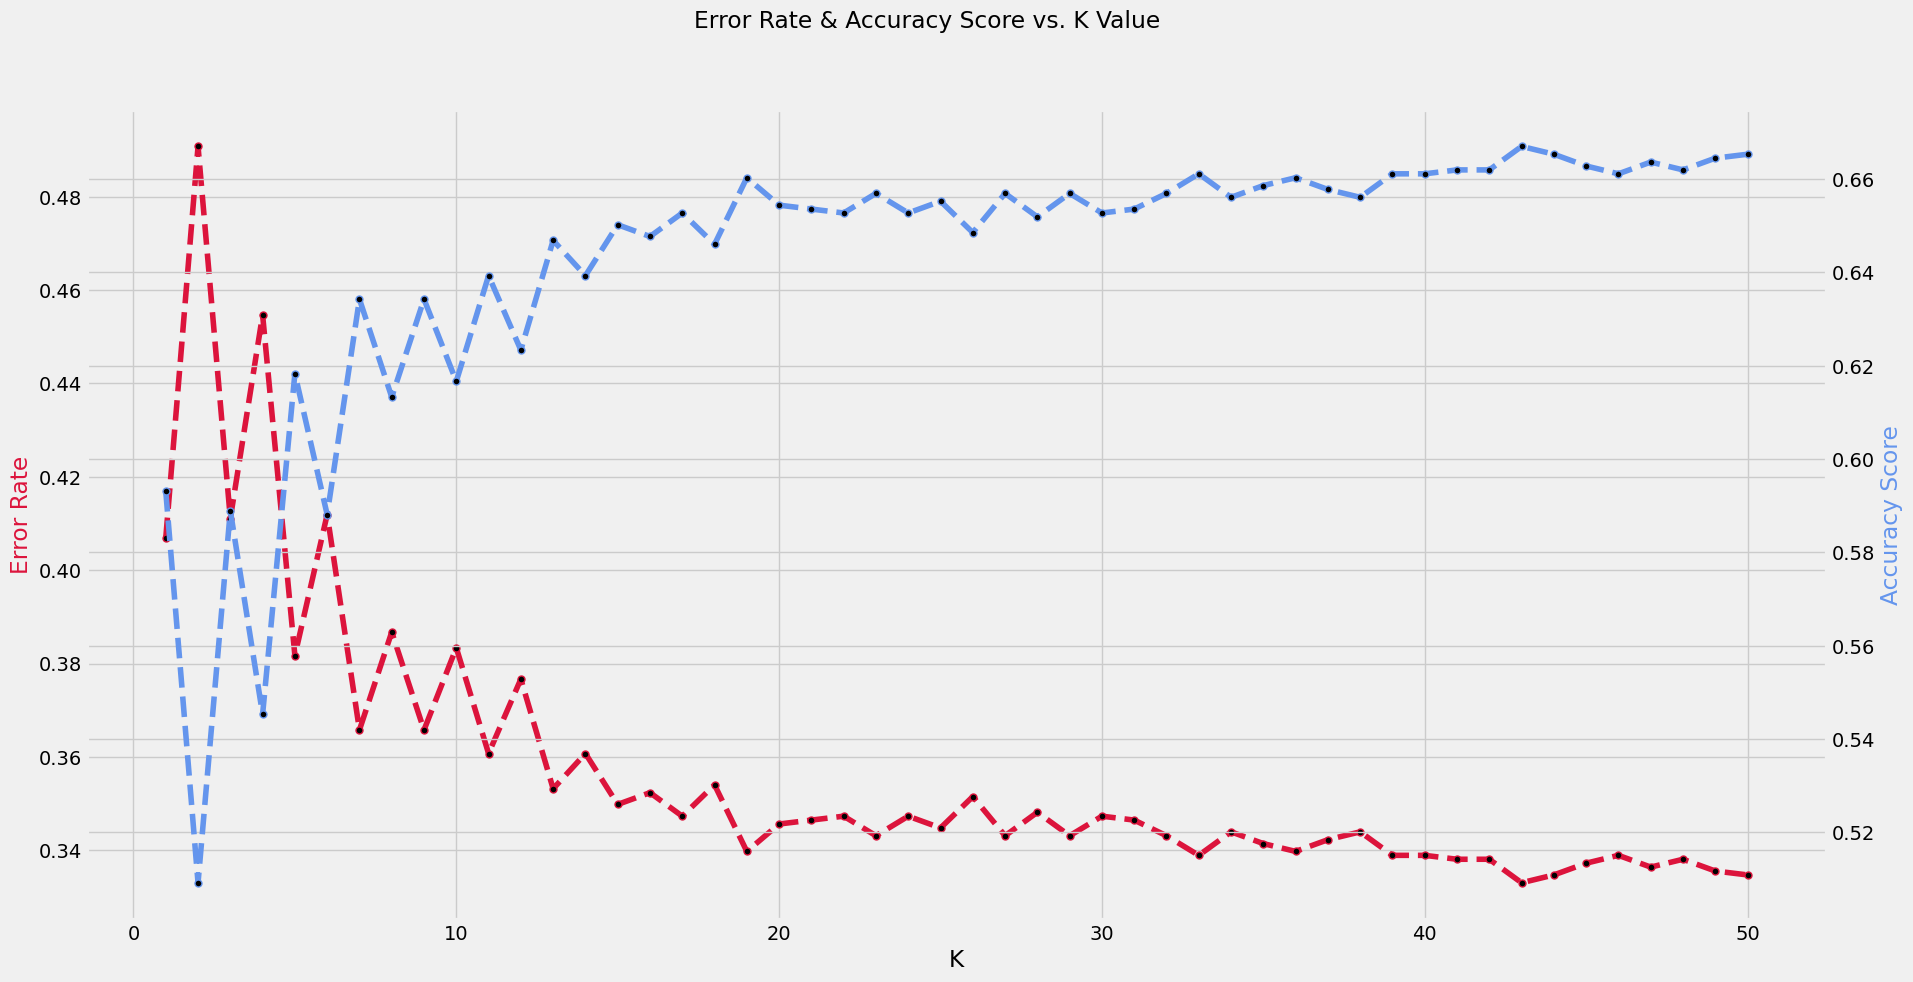

In [33]:
fig, ax1 = plt.subplots(figsize=(20,10))

ax2 = ax1.twinx()
ax1.plot(range(1,51), error_rate, color= 'crimson', linestyle='dashed',  marker='o', markerfacecolor='black', markersize=5)
ax2.plot(range(1,51), acc_score, color='cornflowerblue', linestyle='dashed', marker='o', markerfacecolor='black', markersize=5)

ax1.set_xlabel('K')
ax1.set_ylabel('Error Rate', color='crimson')
ax2.set_ylabel('Accuracy Score', color='cornflowerblue')

fig.suptitle('Error Rate & Accuracy Score vs. K Value');

In [34]:
clf = KNeighborsClassifier(n_neighbors =43)

In [36]:
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=43)

In [37]:
y_pred = clf.predict(X_test)

In [38]:
acc_train = accuracy_score(y_train, clf.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

In [39]:
print(f'\n Training Accuracy \t: {acc_train :0.4} \n Test Accuracy \t\t: {acc_test :0.4}')


 Training Accuracy 	: 0.6495 
 Test Accuracy 		: 0.6669


In [40]:
print(metrics.confusion_matrix(y_test, y_pred))

[[ 12 380]
 [ 17 783]]


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.41      0.03      0.06       392
           1       0.67      0.98      0.80       800

    accuracy                           0.67      1192
   macro avg       0.54      0.50      0.43      1192
weighted avg       0.59      0.67      0.55      1192



In [ ]:
#Trading Strategy

In [42]:
df1 = df[-len(X_test):]
df1['Signal'] = clf.predict(X_test)

In [43]:
# Buy & Hold
df1['Returns'] = np.log(df1['Adj Close']).diff().fillna(0)
cumret = df1['Returns'].cumsum().apply(np.exp)

# KNN Algorithm
df1['Strategy'] = df1['Returns'] * df1['Signal'].shift(1).fillna(0)
cumstg = df1['Strategy'].cumsum().apply(np.exp)

In [44]:
df1.tail(20)

,AAPL,Returns,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,...,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60,Adj Close,Target,Signal,Strategy
Date,,,,,,,,,,,,,,,,,,,,,
2023-11-01,173.741104,0.018565,-0.010692,0.013292,-0.032962,0.011323,0.001783,0.010948,0.020558,0.010414,...,-0.018565,0.013737,-0.019806,0.013344,-0.031613,0.012955,173.741104,1,1,0.018565
2023-11-02,177.336380,0.020482,0.011954,0.014914,-0.017529,0.012652,0.015093,0.011774,0.039516,0.011133,...,-0.019795,0.013698,0.005648,0.013619,-0.002136,0.013185,177.336380,-1,1,0.020482
2023-11-03,176.417572,-0.005195,0.021573,0.014053,-0.012377,0.012453,-0.004744,0.011371,0.031279,0.011209,...,0.001530,0.013190,0.015115,0.013489,-0.006095,0.013201,176.417572,1,1,-0.005195
2023-11-06,178.994186,0.014500,0.035378,0.014562,0.002850,0.013067,0.001340,0.011692,0.031052,0.011198,...,0.003465,0.013230,0.026802,0.013621,0.008067,0.013335,178.994186,1,1,0.014500
2023-11-07,181.580780,0.014347,0.047185,0.014945,0.026020,0.013293,0.019045,0.012083,0.053200,0.011328,...,0.009005,0.013328,0.033443,0.013715,0.013065,0.013409,181.580780,1,1,0.014347
2023-11-08,182.649368,0.005868,0.066637,0.013494,0.039310,0.013081,0.017040,0.012030,0.051785,0.011305,...,-0.006703,0.012994,0.031437,0.013698,0.030196,0.013343,182.649368,1,1,0.005868
2023-11-09,182.169998,-0.002628,0.088922,0.008682,0.038846,0.013093,0.009363,0.012012,0.041985,0.011290,...,-0.028322,0.012701,0.007097,0.013392,0.032539,0.013330,182.169998,1,1,-0.002628
2023-11-10,186.399994,0.022955,0.103939,0.009734,0.076614,0.013139,0.042664,0.012721,0.050297,0.011799,...,-0.006539,0.013129,0.056571,0.013230,0.070156,0.013487,186.399994,-1,1,0.022955
2023-11-13,184.800003,-0.008621,0.083088,0.011389,0.067299,0.013575,0.034770,0.012935,0.033261,0.011905,...,-0.023587,0.013123,0.035386,0.013196,0.058723,0.013544,184.800003,1,1,-0.008621


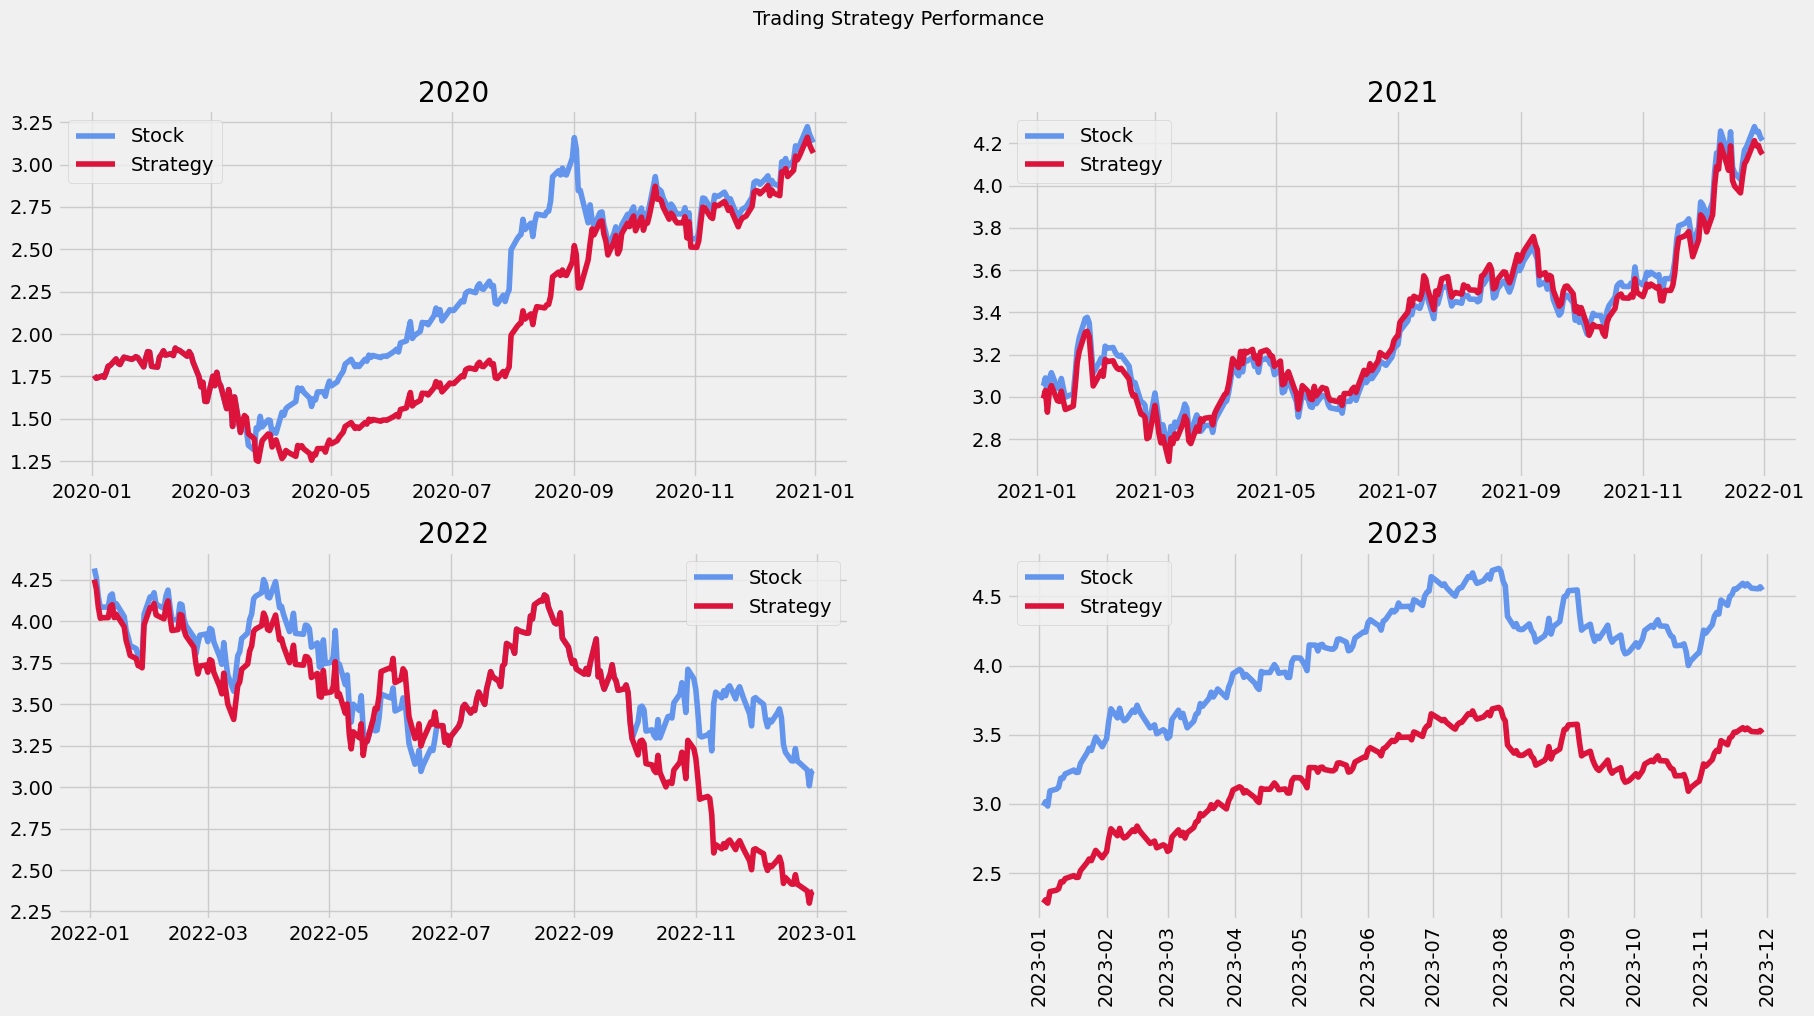

In [45]:
fig, ax = plt.subplots(2,2, figsize=(20,10))

ax[0,0].plot(cumret['2020'], label ='Stock', color ='cornflowerblue')
ax[0,0].plot(cumstg['2020'], label ='Strategy', color ='crimson')

ax[0,1].plot(cumret['2021'], label ='Stock', color ='cornflowerblue')
ax[0,1].plot(cumstg['2021'], label ='Strategy', color ='crimson')

ax[1,0].plot(cumret['2022'], label ='Stock', color ='cornflowerblue')
ax[1,0].plot(cumstg['2022'], label ='Strategy', color ='crimson')

ax[1,1].plot(cumret['2023'], label ='Stock', color ='cornflowerblue')
ax[1,1].plot(cumstg['2023'], label ='Strategy', color ='crimson')
ax[1,1].tick_params(axis='x', rotation=90)


ax[0,0].set_title('2020'), ax[0,1].set_title('2021'), ax[1,0].set_title('2022'), ax[1,1].set_title('2023')

ax[0,0].legend(), ax[0,1].legend(), ax[1,0].legend(), ax[1,1].legend()

fig.suptitle('Trading Strategy Performance', fontsize=14);